# Diabetes Prediction — Full Google Colab Notebook



In [1]:
# Upload dataset.
from google.colab import files
print('Please upload your CSV file (e.g. diabetes.csv). After upload, run the next cell to load it.')
uploaded = files.upload()  # select diabetes.csv


Please upload your CSV file (e.g. diabetes.csv). After upload, run the next cell to load it.


Saving diabetes.csv to diabetes.csv


In [2]:
# Load dataset into a dataframe. If you uploaded a file via the previous cell, it will be used.
import io, os, pandas as pd
try:
    if 'uploaded' in globals() and len(uploaded) > 0:
        fname = list(uploaded.keys())[0]
        df = pd.read_csv(io.BytesIO(uploaded[fname]))
        print(f'Loaded uploaded file: {fname}')
    else:
        if os.path.exists('diabetes.csv'):
            df = pd.read_csv('diabetes.csv')
            print('Loaded diabetes.csv from current directory.')
        elif os.path.exists('/mnt/data/diabetes.csv'):
            df = pd.read_csv('/mnt/data/diabetes.csv')
            print('Loaded /mnt/data/diabetes.csv')
        else:
            raise FileNotFoundError('No dataset found. Please upload diabetes.csv via the upload cell.')
except Exception as e:
    raise e

# Quick peek
df.shape, df.columns.tolist()


Loaded uploaded file: diabetes.csv


((768, 9),
 ['Pregnancies',
  'Glucose',
  'BloodPressure',
  'SkinThickness',
  'Insulin',
  'BMI',
  'DiabetesPedigreeFunction',
  'Age',
  'Outcome'])

In [3]:
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [4]:
df.info()
df.describe().T

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


,count,mean,std,min,25%,50%,75%,max
Pregnancies,768.0,3.845052,3.369578,0.000,1.00000,3.0000,6.00000,17.00
Glucose,768.0,120.894531,31.972618,0.000,99.00000,117.0000,140.25000,199.00
BloodPressure,768.0,69.105469,19.355807,0.000,62.00000,72.0000,80.00000,122.00
SkinThickness,768.0,20.536458,15.952218,0.000,0.00000,23.0000,32.00000,99.00
Insulin,768.0,79.799479,115.244002,0.000,0.00000,30.5000,127.25000,846.00
BMI,768.0,31.992578,7.884160,0.000,27.30000,32.0000,36.60000,67.10
DiabetesPedigreeFunction,768.0,0.471876,0.331329,0.078,0.24375,0.3725,0.62625,2.42
Age,768.0,33.240885,11.760232,21.000,24.00000,29.0000,41.00000,81.00
Outcome,768.0,0.348958,0.476951,0.000,0.00000,0.0000,1.00000,1.00


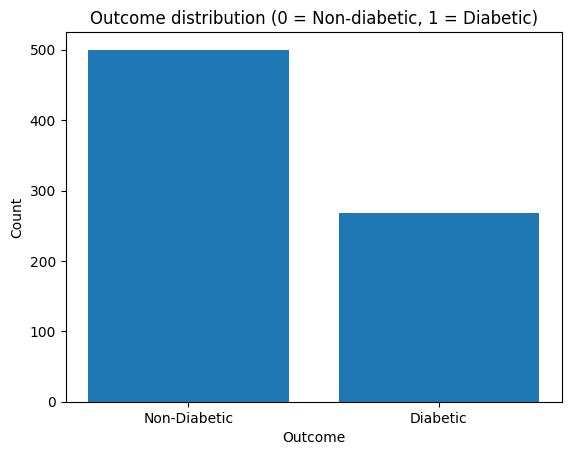

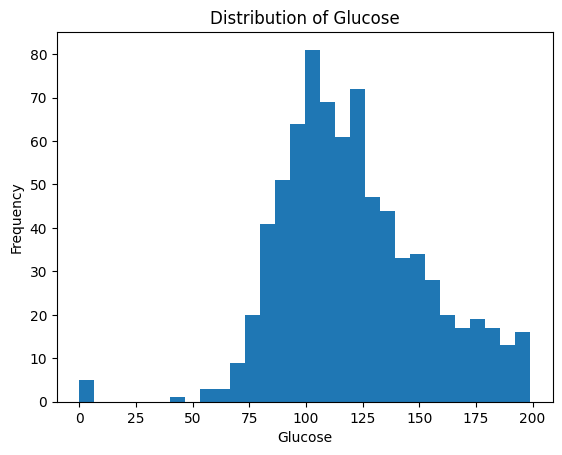

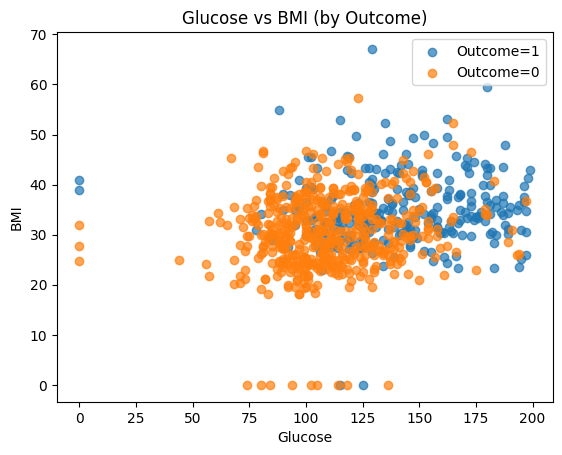

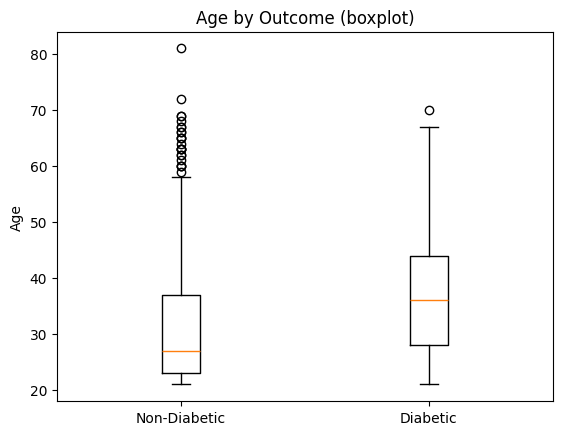

In [6]:
# EDA: target distribution, key feature relationships, and boxplots
import matplotlib.pyplot as plt
import numpy as np

# Target distribution
plt.figure()
labels, counts = np.unique(df['Outcome'], return_counts=True)
plt.bar(labels, counts)
plt.xticks(labels, ['Non-Diabetic','Diabetic'])
plt.title('Outcome distribution (0 = Non-diabetic, 1 = Diabetic)')
plt.xlabel('Outcome')
plt.ylabel('Count')
plt.show()

# Histogram of Glucose
plt.figure()
plt.hist(df['Glucose'].dropna(), bins=30)
plt.title('Distribution of Glucose')
plt.xlabel('Glucose')
plt.ylabel('Frequency')
plt.show()

# Scatter: Glucose vs BMI colored by Outcome (use marker style to separate)
plt.figure()
for outcome in df['Outcome'].unique():
    subset = df[df['Outcome'] == outcome]
    plt.scatter(subset['Glucose'], subset['BMI'], label=f'Outcome={outcome}', alpha=0.7)
plt.xlabel('Glucose')
plt.ylabel('BMI')
plt.title('Glucose vs BMI (by Outcome)')
plt.legend()
plt.show()

# Boxplot of Age by Outcome
plt.figure()
data0 = df[df['Outcome']==0]['Age'].dropna()
data1 = df[df['Outcome']==1]['Age'].dropna()
plt.boxplot([data0, data1], tick_labels=['Non-Diabetic','Diabetic'])
plt.title('Age by Outcome (boxplot)')
plt.ylabel('Age')
plt.show()


In [8]:
# Preprocessing: handle zeros in features where zeros are invalid medical values
import numpy as np
df_clean = df.copy()

cols_with_zero_invalid = ['Glucose','BloodPressure','SkinThickness','Insulin','BMI']
for c in cols_with_zero_invalid:
    if c in df_clean.columns:
        df_clean[c] = df_clean[c].replace(0, np.nan)

for c in cols_with_zero_invalid:
    if c in df_clean.columns:
        df_clean[c] = df_clean[c].fillna(df_clean[c].median())


X = df_clean.drop('Outcome', axis=1)
y = df_clean['Outcome']

from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print('Shapes:', X_train.shape, X_test.shape, y_train.shape, y_test.shape)


Shapes: (614, 8) (154, 8) (614,) (154,)


In [9]:
# Build preprocessing pipeline (StandardScaler) to be used with models
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

import pandas as pd
X_train_scaled = pd.DataFrame(X_train_scaled, columns=X.columns, index=X_train.index)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=X.columns, index=X_test.index)
X_train_scaled.head()


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age
353,-0.851355,-1.056427,-0.826740,-1.918187,-1.203361,-0.769477,0.310794,-0.792169
711,0.356576,0.144399,0.477772,-0.229874,-1.470195,-0.417498,-0.116439,0.561034
373,-0.549372,-0.556083,-1.152868,1.233330,-0.555335,0.359790,-0.764862,-0.707594
46,-0.851355,0.811525,-1.315932,-0.004766,-0.161437,-0.402832,0.262314,-0.369293
682,-1.153338,-0.889646,-0.663676,1.120776,-0.415565,1.782373,-0.337630,-0.961320


In [10]:
# 1) Logistic Regression (baseline)
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix

log_clf = LogisticRegression(max_iter=1000, random_state=42)
log_clf.fit(X_train_scaled, y_train)
y_pred_log = log_clf.predict(X_test_scaled)
y_prob_log = log_clf.predict_proba(X_test_scaled)[:,1]

metrics = {}
metrics['LogisticRegression'] = {
    'accuracy': accuracy_score(y_test, y_pred_log),
    'precision': precision_score(y_test, y_pred_log),
    'recall': recall_score(y_test, y_pred_log),
    'f1': f1_score(y_test, y_pred_log),
    'roc_auc': roc_auc_score(y_test, y_prob_log)
}
metrics['LogisticRegression']


{'accuracy': 0.7077922077922078,
 'precision': 0.6,
 'recall': 0.5,
 'f1': 0.5454545454545454,
 'roc_auc': np.float64(0.812962962962963)}

In [11]:
# 2) Random Forest with GridSearchCV (simple grid)
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV

rf = RandomForestClassifier(random_state=42)
rf_params = {
    'n_estimators':[100,200],
    'max_depth':[None,10,20],
    'min_samples_split':[2,5]
}
rf_gs = GridSearchCV(rf, rf_params, cv=5, scoring='roc_auc', n_jobs=-1)
rf_gs.fit(X_train_scaled, y_train)
best_rf = rf_gs.best_estimator_
y_pred_rf = best_rf.predict(X_test_scaled)
y_prob_rf = best_rf.predict_proba(X_test_scaled)[:,1]

metrics['RandomForest'] = {
    'accuracy': accuracy_score(y_test, y_pred_rf),
    'precision': precision_score(y_test, y_pred_rf),
    'recall': recall_score(y_test, y_pred_rf),
    'f1': f1_score(y_test, y_pred_rf),
    'roc_auc': roc_auc_score(y_test, y_prob_rf),
    'best_params': rf_gs.best_params_
}
metrics['RandomForest']


{'accuracy': 0.7402597402597403,
 'precision': 0.6458333333333334,
 'recall': 0.5740740740740741,
 'f1': 0.6078431372549019,
 'roc_auc': np.float64(0.8083333333333335),
 'best_params': {'max_depth': 10, 'min_samples_split': 5, 'n_estimators': 200}}

In [12]:
# 3) Support Vector Machine (SVM) with GridSearchCV - tune C and gamma for RBF kernel
from sklearn.svm import SVC

svm = SVC(probability=True, random_state=42)
svm_params = {
    'C': [0.1, 1, 10, 100],
    'gamma': ['scale', 0.001, 0.01, 0.1, 1],
    'kernel': ['rbf']
}

svm_gs = GridSearchCV(svm, svm_params, cv=5, scoring='roc_auc', n_jobs=-1)
svm_gs.fit(X_train_scaled, y_train)
best_svm = svm_gs.best_estimator_
y_pred_svm = best_svm.predict(X_test_scaled)
y_prob_svm = best_svm.predict_proba(X_test_scaled)[:,1]

metrics['SVM'] = {
    'accuracy': accuracy_score(y_test, y_pred_svm),
    'precision': precision_score(y_test, y_pred_svm),
    'recall': recall_score(y_test, y_pred_svm),
    'f1': f1_score(y_test, y_pred_svm),
    'roc_auc': roc_auc_score(y_test, y_prob_svm),
    'best_params': svm_gs.best_params_
}
metrics['SVM']


{'accuracy': 0.6948051948051948,
 'precision': 0.5777777777777777,
 'recall': 0.48148148148148145,
 'f1': 0.5252525252525253,
 'roc_auc': np.float64(0.8168518518518518),
 'best_params': {'C': 100, 'gamma': 0.001, 'kernel': 'rbf'}}

In [13]:
# Compare model metrics in a neat table
import pandas as pd
metrics_df = pd.DataFrame(metrics).T
metrics_df[['accuracy','precision','recall','f1','roc_auc']]


,accuracy,precision,recall,f1,roc_auc
LogisticRegression,0.707792,0.6,0.5,0.545455,0.812963
RandomForest,0.74026,0.645833,0.574074,0.607843,0.808333
SVM,0.694805,0.577778,0.481481,0.525253,0.816852



--- Logistic ---


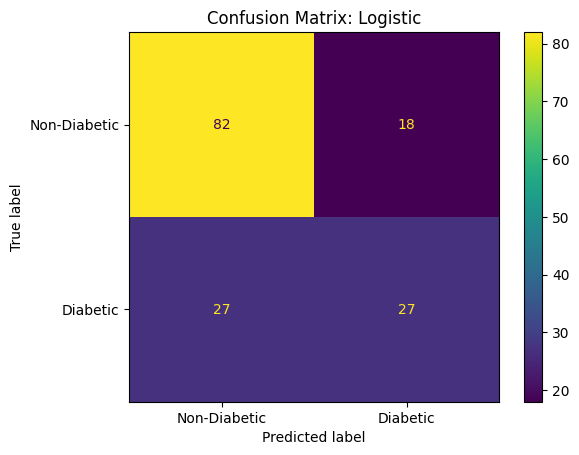


--- RandomForest ---


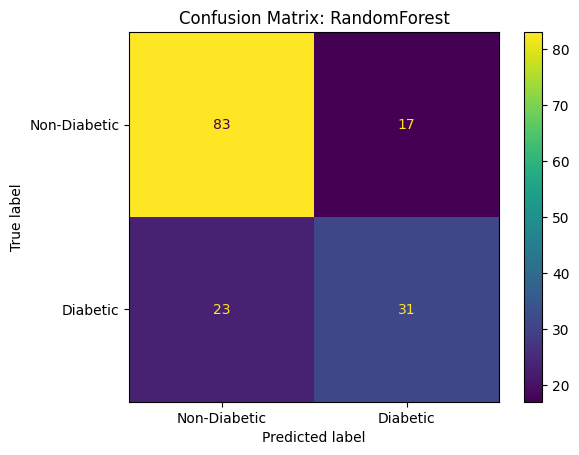


--- SVM ---


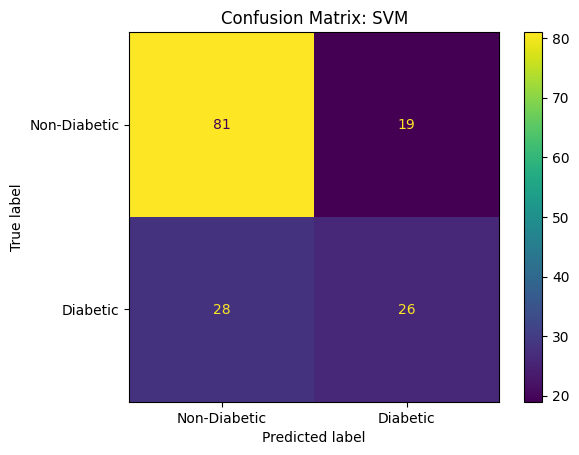

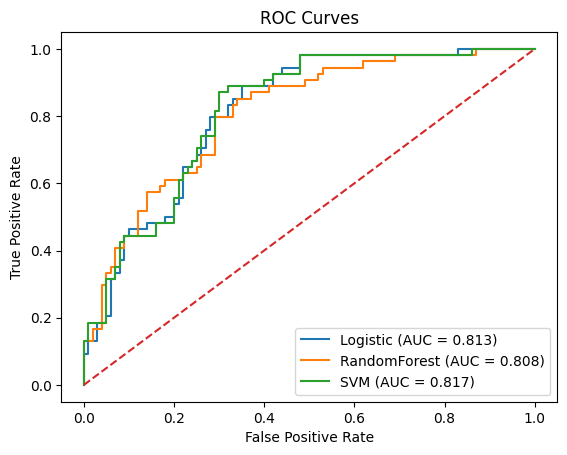

In [14]:
# Confusion matrices and ROC curves for the three models
from sklearn.metrics import RocCurveDisplay, ConfusionMatrixDisplay, roc_curve, auc
import matplotlib.pyplot as plt

models = {
    'Logistic': (log_clf, y_prob_log, y_pred_log),
    'RandomForest': (best_rf, y_prob_rf, y_pred_rf),
    'SVM': (best_svm, y_prob_svm, y_pred_svm)
}

# Confusion matrices
for name, (model, y_prob, y_pred) in models.items():
    print('\n---', name, '---')
    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Non-Diabetic','Diabetic'])
    disp.plot()
    plt.title(f'Confusion Matrix: {name}')
    plt.show()

# ROC curves
plt.figure()
for name, (model, y_prob, y_pred) in models.items():
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    roc_auc = auc(fpr,tpr)
    plt.plot(fpr, tpr, label=f'{name} (AUC = {roc_auc:.3f})')
plt.plot([0,1],[0,1],'--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves')
plt.legend()
plt.show()


## Analysis & Interpretation

**RECAP:**

- **SVM achieved the highest ROC AUC (0.817)**, showing it separates diabetic vs non-diabetic patients well in terms of ranking risk scores.  
- **Random Forest had the best overall accuracy (0.74) and F1 score (0.61)**, giving a better balance between precision (0.65) and recall (0.57).  
- **Logistic Regression performed decently** with ROC AUC (0.813), but had lower recall (0.50), meaning it missed more diabetic cases compared to RF.  

**Why one model outperformed the others:**

- **Logistic Regression**: Limited to linear boundaries, but still competitive since the dataset has moderately linear relationships (e.g., glucose vs outcome).  
- **Random Forest**: Outperformed in accuracy and F1 because it captures non-linear interactions (e.g., glucose × BMI × insulin). The tuned parameters (`max_depth=10, min_samples_split=5, n_estimators=200`) helped prevent overfitting while improving generalization.  
- **SVM**: Despite tuning (`C=100, gamma=0.001`), it underperformed in accuracy/F1 but excelled in ROC AUC. This suggests its decision function ranks patients well but may need probability calibration or threshold adjustment for better discrete classification.  

In [16]:
# Prediction function using the best model based on ROC AUC
# Decide best model by roc_auc
best_model_name = metrics_df['roc_auc'].idxmax()
print('Best model chosen by ROC AUC:', best_model_name)
best_model = {'LogisticRegression': log_clf, 'RandomForest': best_rf, 'SVM': best_svm}[best_model_name]

def predict_patient(input_dict):
    # input_dict should map feature name -> value for each column in X.columns
    x = pd.DataFrame([input_dict], columns=X.columns)
    x_scaled = scaler.transform(x)
    x_scaled = pd.DataFrame(x_scaled, columns=X.columns)  # <--- Fix
    pred = best_model.predict(x_scaled)[0]
    prob = best_model.predict_proba(x_scaled)[0,1]
    return {'prediction': int(pred), 'diabetes_probability': float(prob)}


# Example usage (replace with real patient values)
example = {c: float(X[c].median()) for c in X.columns}
print('Example prediction (median values):', predict_patient(example))


Best model chosen by ROC AUC: SVM
Example prediction (median values): {'prediction': 0, 'diabetes_probability': 0.24181650694558576}


In [17]:
# Optional: save the trained best model and scaler for later use
import joblib
joblib.dump(best_model, 'best_model.joblib')
joblib.dump(scaler, 'scaler.joblib')
print('Saved best_model.joblib and scaler.joblib to the working directory.')


Saved best_model.joblib and scaler.joblib to the working directory.
